# Desafio SEFAZ Maceió - Análise de Execução Orçamentária

In [1]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt

con = duckdb.connect("data/gold/finbra_analytics.duckdb")

## 1. Verificação da Base de Dados

In [2]:
df_teste = con.sql("SELECT * FROM despesas_funcao LIMIT 30").df()

display(df_teste)

,Instituição,Cod.IBGE,UF,População,Coluna,Conta,Identificador da Conta,Valor,Ano,Função,Subfunção,Região
0,Prefeitura Municipal de Rio Branco - AC,1200401,AC,407319,Despesas Empenhadas,Despesas Exceto Intraorçamentárias,siconfi-cor_TotalDespesas,8.748853e+08,2020,NaN,NaN,Norte
1,Prefeitura Municipal de Rio Branco - AC,1200401,AC,407319,Despesas Empenhadas,01 - Legislativa,siconfi-cor_TotalDespesas,2.901406e+07,2020,01 - Legislativa,NaN,Norte
2,Prefeitura Municipal de Rio Branco - AC,1200401,AC,407319,Despesas Empenhadas,01.031 - Ação Legislativa,siconfi-cor_TotalDespesas,2.901406e+07,2020,01 - Legislativa,01.031 - Ação Legislativa,Norte
3,Prefeitura Municipal de Rio Branco - AC,1200401,AC,407319,Despesas Empenhadas,03 - Essencial à Justiça,siconfi-cor_TotalDespesas,1.882290e+07,2020,03 - Essencial à Justiça,NaN,Norte
4,Prefeitura Municipal de Rio Branco - AC,1200401,AC,407319,Despesas Empenhadas,03.092 - Representação Judicial e Extrajudicial,siconfi-cor_TotalDespesas,1.882290e+07,2020,03 - Essencial à Justiça,03.092 - Representação Judicial e Extrajudicial,Norte
5,Prefeitura Municipal de Rio Branco - AC,1200401,AC,407319,Despesas Empenhadas,04 - Administração,siconfi-cor_TotalDespesas,8.225880e+07,2020,04 - Administração,NaN,Norte
6,Prefeitura Municipal de Rio Branco - AC,1200401,AC,407319,Despesas Empenhadas,04.121 - Planejamento e Orçamento,siconfi-cor_TotalDespesas,5.105576e+06,2020,04 - Administração,04.121 - Planejamento e Orçamento,Norte
7,Prefeitura Municipal de Rio Branco - AC,1200401,AC,407319,Despesas Empenhadas,04.122 - Administração Geral,siconfi-cor_TotalDespesas,5.159207e+07,2020,04 - Administração,04.122 - Administração Geral,Norte
8,Prefeitura Municipal de Rio Branco - AC,1200401,AC,407319,Despesas Empenhadas,04.123 - Administração Financeira,siconfi-cor_TotalDespesas,1.893283e+07,2020,04 - Administração,04.123 - Administração Financeira,Norte
9,Prefeitura Municipal de Rio Branco - AC,1200401,AC,407319,Despesas Empenhadas,04.124 - Controle Interno,siconfi-cor_TotalDespesas,1.064200e+04,2020,04 - Administração,04.124 - Controle Interno,Norte


## 2. Indicador de Eficiência: Taxa de Execução Financeira

### Ano 2020

In [3]:
# Query focada exclusivamente no ano de 2020
query_2020 = """
SELECT 
    "Instituição" AS "Prefeitura",

    ROUND(SUM(CASE WHEN coluna = 'Despesas Empenhadas' THEN valor ELSE 0 END) / 1e9, 2) AS "Empenhado (Bilhões R$)",
    ROUND(SUM(CASE WHEN coluna = 'Despesas Pagas' THEN valor ELSE 0 END) / 1e9, 2) AS "Pago (Bilhões R$)",

    ROUND(
        (SUM(CASE WHEN coluna = 'Despesas Pagas' THEN valor ELSE 0 END) / 
         NULLIF(SUM(CASE WHEN coluna = 'Despesas Empenhadas' THEN valor ELSE 0 END), 0)) * 100, 
        1
    ) AS "Taxa de Execução (%)"
FROM despesas_funcao
WHERE Ano = 2020 AND "Função" IS NOT NULL
GROUP BY "Prefeitura"
ORDER BY "Taxa de Execução (%)" DESC; -- Ranking da maior taxa para a menor
"""

# Executa e salva no DataFrame de 2020
df_2020 = con.sql(query_2020).df()

# Exibe a tabela completa de 2020 para análise
display(df_2020)

,Prefeitura,Empenhado (Bilhões R$),Pago (Bilhões R$),Taxa de Execução (%)
0,Prefeitura Municipal de Goiânia - GO,11.38,11.23,98.7
1,Prefeitura Municipal de Aracaju - SE,3.74,3.64,97.4
2,Prefeitura Municipal de João Pessoa - PB,4.33,4.20,97.0
3,Prefeitura Municipal de Recife - PE,10.52,10.17,96.7
4,Prefeitura Municipal de Salvador - BA,14.62,14.12,96.6
5,Prefeitura Municipal de Maceió - AL,4.94,4.76,96.4
6,Prefeitura Municipal de Cuiabá - MT,5.27,5.06,96.1
7,Prefeitura Municipal de Manaus - AM,12.57,12.08,96.1
8,Prefeitura Municipal de Rio Branco - AC,1.75,1.68,96.0
9,Prefeitura Municipal de Fortaleza - CE,17.04,16.21,95.1


Em 2020, a cidade que apresentou a maior Taxa de Execução foi Goiânia (98,7%). Já Macapá, apresentou a pior Taxa de Execução (79,6%) do país.

#### Cálculos Estatísticos de 2020 (Média e Moda)

In [4]:
# 1. Média de execução do Brasil em 2020
media_2020 = df_2020["Taxa de Execução (%)"].mean()

# 2. Moda de execução em 2020
moda_2020 = df_2020["Taxa de Execução (%)"].round(0).mode()[0]

# 3. Taxa específica de Maceió em 2020
maceio_2020_df = df_2020[df_2020["Prefeitura"].str.contains("Maceió", case=False)]
taxa_maceio_2020 = maceio_2020_df["Taxa de Execução (%)"].values[0]

# Resultados
print(f"--- INDICADORES DE 2020 ---")
print(f"Taxa de Execução Média do Brasil: {media_2020:.1f}%")
print(f"Taxa de Execução mais comum no Brasil (Moda): {int(moda_2020)}%")
print(f"Taxa de Execução de Maceió: {taxa_maceio_2020}%")

--- INDICADORES DE 2020 ---
Taxa de Execução Média do Brasil: 92.6%
Taxa de Execução mais comum no Brasil (Moda): 94%
Taxa de Execução de Maceió: 96.4%


Os cálculos estatísticos de 2020, demonstram uma taxa média de execução alta (92,6%). Além disso, a maior parte das capitais possuiam uma taxa de execução acima da média, evidenciando uma tendência positiva de responsabilidade fiscal nas capitais brasileiras.
Maceió se destaca na 6ª posição de melhor taxa de execução do país (96,4%).

##### O Rankinkg Gráfico e a posição de Maceió

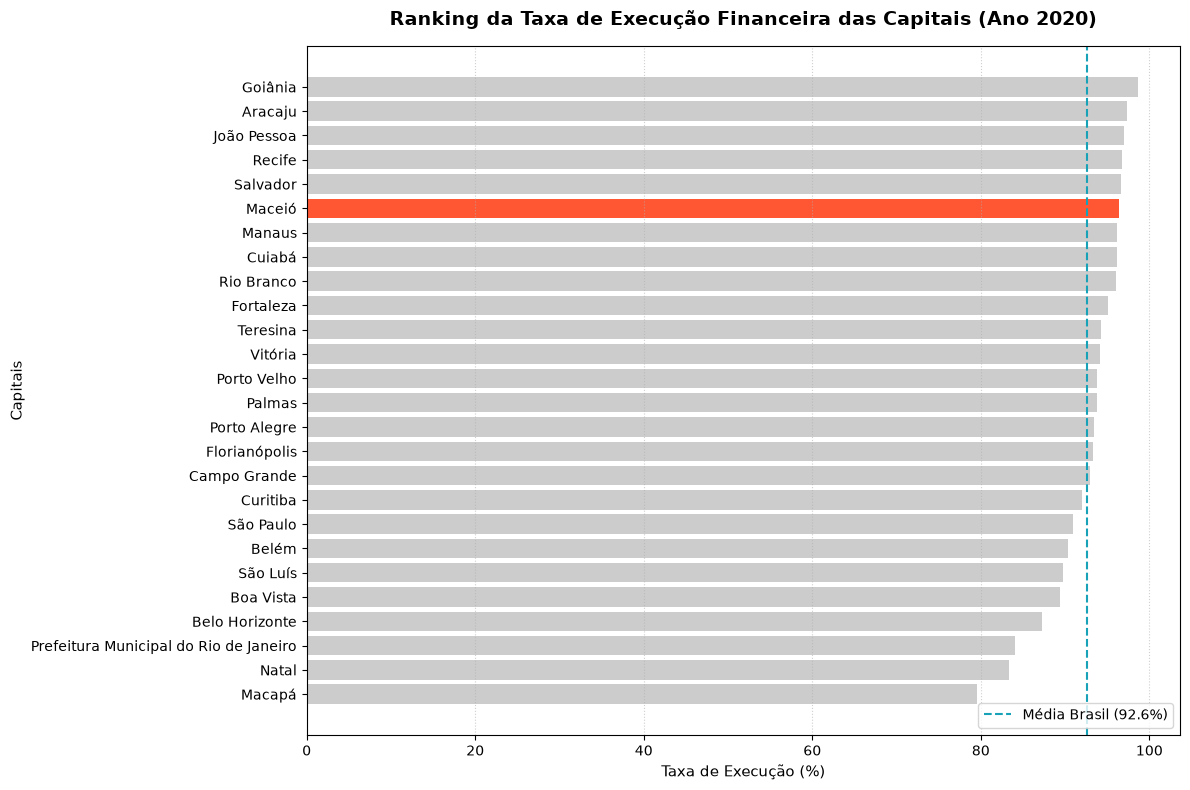

In [5]:
df_grafico_2020 = df_2020.sort_values(by="Taxa de Execução (%)", ascending=True)

# Retira o "Prefeitura Municipal de...")
df_grafico_2020["Cidade"] = df_grafico_2020["Prefeitura"].str.replace("Prefeitura Municipal de ", "").str.split(" -").str[0]

# 2. Configurações do gráfico
plt.figure(figsize=(12, 8))

cores = ['#FF5733' if "Maceió" in prefeitura else '#CCCCCC' for prefeitura in df_grafico_2020["Prefeitura"]]

plt.barh(df_grafico_2020["Cidade"], df_grafico_2020["Taxa de Execução (%)"], color=cores)

plt.axvline(media_2020, color='#17a2b8', linestyle='--', linewidth=1.5, label=f'Média Brasil ({media_2020:.1f}%)')

plt.title("Ranking da Taxa de Execução Financeira das Capitais (Ano 2020)", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Taxa de Execução (%)", fontsize=11)
plt.ylabel("Capitais", fontsize=11)
plt.legend(loc="lower right")
plt.grid(axis='x', linestyle=':', alpha=0.6)

# Exibe o gráfico
plt.tight_layout()
plt.show()

#### Funções que mais receberam Empenho e Pagamento no Brasil (2020)

In [6]:
# Query para listar as funções com maiores gastos no Brasil em 2020
query_funcoes_brasil = """
SELECT 
    "Função",
    -- Totais em Bilhões
    ROUND(SUM(CASE WHEN coluna = 'Despesas Empenhadas' THEN valor ELSE 0 END) / 1e9, 2) AS "Total Empenhado (Bilhões R$)",
    ROUND(SUM(CASE WHEN coluna = 'Despesas Pagas' THEN valor ELSE 0 END) / 1e9, 2) AS "Total Pago (Bilhões R$)",
    
    -- 2. Percentual do Empenhado da linha sobre o Empenhado Total do Brasil
    ROUND(
        (SUM(CASE WHEN coluna = 'Despesas Empenhadas' THEN valor ELSE 0 END) / 
         SUM(SUM(CASE WHEN coluna = 'Despesas Empenhadas' THEN valor ELSE 0 END)) OVER()) * 100, 
        2
    ) AS "% do Empenhado Total",
    
    -- 3. Percentual do Pago da linha sobre o Pago Total do Brasil
    ROUND(
        (SUM(CASE WHEN coluna = 'Despesas Pagas' THEN valor ELSE 0 END) / 
         SUM(SUM(CASE WHEN coluna = 'Despesas Pagas' THEN valor ELSE 0 END)) OVER()) * 100, 
        2
    ) AS "% do Pago Total"
    
FROM despesas_funcao
WHERE Ano = 2020 AND "Função" IS NOT NULL
GROUP BY "Função"
ORDER BY "Total Pago (Bilhões R$)" DESC; -- Ordenado por onde o dinheiro realmente saiu
"""

df_funcoes_brasil = con.sql(query_funcoes_brasil).df()
display(df_funcoes_brasil.head(5))

,Função,Total Empenhado (Bilhões R$),Total Pago (Bilhões R$),% do Empenhado Total,% do Pago Total
0,10 - Saúde,92.45,85.13,25.40,25.65
1,12 - Educação,71.16,62.31,19.55,18.78
2,09 - Previdência Social,54.61,52.43,15.00,15.80
3,15 - Urbanismo,40.60,35.51,11.16,10.70
4,04 - Administração,24.05,22.60,6.61,6.81


- Saúde como Prioridade: Pouco mais de um quarto de todo o dinheiro liquidado no Brasil foi para a Saúde, o que reflete os esforços de combate à Covid-19 no primeiro ano da pandemia.
- Trio de Peso: Quase dois terços de todo o orçamento executado pelas capitais em 2020 foram destinados a apenas três áreas (saúde, educação e previdência social).

##### Detalhemento por Subfunção

In [7]:
# Query de Subfunções com representatividade sobre o total pago do país em 2020
query_subfuncoes_brasil = """
SELECT
    "Função",
    "Subfunção",
    -- 1. Total Pago da Subfunção em Bilhões de Reais
    ROUND(SUM(CASE WHEN coluna = 'Despesas Pagas' THEN valor ELSE 0 END) / 1e9, 2) AS "Total Pago (Bilhões R$)",
    
    -- 2. Percentual que esta subfunção representa sobre o TOTAL PAGO do Brasil inteiro
    ROUND(
        (SUM(CASE WHEN coluna = 'Despesas Pagas' THEN valor ELSE 0 END) / 
         SUM(SUM(CASE WHEN coluna = 'Despesas Pagas' THEN valor ELSE 0 END)) OVER()) * 100, 
        2
    ) AS "% do Pago Total País"

FROM despesas_funcao
WHERE Ano = 2020
  AND "Função" IS NOT NULL    
  AND "Subfunção" IS NOT NULL
GROUP BY "Função", "Subfunção"
ORDER BY "Total Pago (Bilhões R$)" DESC;
"""

df_subfuncoes_brasil = con.sql(query_subfuncoes_brasil).df()
display(df_subfuncoes_brasil.head(5))

,Função,Subfunção,Total Pago (Bilhões R$),% do Pago Total País
0,09 - Previdência Social,09.272 - Previdência do Regime Estatutário,24.03,14.48
1,10 - Saúde,10.302 - Assistência Hospitalar e Ambulatorial,22.17,13.36
2,12 - Educação,12.361 - Ensino Fundamental,17.26,10.40
3,10 - Saúde,10.301 - Atenção Básica,10.77,6.49
4,12 - Educação,12.365 - Educação Infantil,10.05,6.06


- Previdência: Sozinha, a folha de pagamento de aposentados e pensionistas do funcionalismo público consumiu mais dinheiro do que qualquer outra ação governamental do país.
- Educação: Constitucionalmente, os municípios dividem a responsabilidade do Ensino Fundamental com os Estados, mas são os únicos responsáveis pela Educação Infantil. No entanto, os dados mostram que há mais investimento no Ensino Fundamental.
- Essas 5 subfunções controlam mais da metade de todo o dinheiro pago por todas as capitais do país (somam cerca de 50% do orçamento total). Isso significa que o resto das subfunções (segurança, cultura, turismo, habitação, saneamento, esporte...) precisa sobreviver dividindo os outros 50%.

##### Detalhamento por Região do País

In [8]:
# Pegar o Total Pago por Região
query_regioes_base = """
SELECT 
    "Região",
    ROUND(SUM(CASE WHEN coluna = 'Despesas Pagas' THEN valor ELSE 0 END) / 1e9, 2) AS "Total Pago Região (Bilhões R$)"
FROM despesas_funcao
WHERE Ano = 2020
  AND "Função" IS NOT NULL
GROUP BY "Região"
ORDER BY "Total Pago Região (Bilhões R$)" DESC;
"""

df_regioes_total = con.sql(query_regioes_base).df()

# Detalhar a Função com maior investimento
query_detalhe = """
SELECT 
    "Região",
    "Função" AS "Função Maior Investimento",
    ROUND(SUM(CASE WHEN coluna = 'Despesas Pagas' THEN valor ELSE 0 END) / 1e9, 2) AS "Gasto da Função (Bilhões R$)"
FROM despesas_funcao
WHERE Ano = 2020 AND "Função" IS NOT NULL
GROUP BY "Região", "Função"
ORDER BY "Região", "Gasto da Função (Bilhões R$)" DESC;
"""
df_detalhe_bruto = con.sql(query_detalhe).df()

# Filtro da maior função de cada região
df_campeas = df_detalhe_bruto.groupby("Região").first().reset_index()

# merge das tabelas
df_regioes_final = pd.merge(df_regioes_total, df_campeas, on="Região")

# Cálculo da porcentagem 
df_regioes_final["% da Função na Região"] = round(
    (df_regioes_final["Gasto da Função (Bilhões R$)"] / df_regioes_final["Total Pago Região (Bilhões R$)"]) * 100, 
    2
)

display(df_regioes_final)

,Região,Total Pago Região (Bilhões R$),Função Maior Investimento,Gasto da Função (Bilhões R$),% da Função na Região
0,Sudeste,178.33,10 - Saúde,41.13,23.06
1,Nordeste,69.85,10 - Saúde,21.82,31.24
2,Sul,31.26,10 - Saúde,8.17,26.14
3,Norte,28.42,10 - Saúde,6.23,21.92
4,Centro-Oeste,23.97,10 - Saúde,7.78,32.46


- Saúde foi o setor que mais recebeu investimentos (despesas pagas) em 2020, o que reforça a crise sanitária que ocorreu no país neste ano.
- Nordeste e Centro-Oeste foram as regiões que mais comprometeram seu orçamento com este setor.
- Embora, o Sudeste seja a segunda região a investir menos em Saúde em proporção ao seu orçamento total, ainda assim, em valores absolutos, investiu quase o mesmo que a soma dos investimentos das outras quatro regiões juntas, o que evidencia a disparidade econômica entre as regiões.

In [9]:
# Pegar o Total Pago por Região
query_regioes_base = """
SELECT 
    "Região",
    ROUND(SUM(CASE WHEN coluna = 'Despesas Pagas' THEN valor ELSE 0 END) / 1e9, 2) AS "Total Pago Região (Bilhões R$)"
FROM despesas_funcao
WHERE Ano = 2020
  AND "Função" IS NOT NULL
GROUP BY "Região"
ORDER BY "Total Pago Região (Bilhões R$)" DESC;
"""

df_regioes_total = con.sql(query_regioes_base).df()

# Detalhar a Função com maior investimento
query_detalhe = """
SELECT 
    "Região",
    "Subfunção" AS "Subfunção Maior Investimento",
    ROUND(SUM(CASE WHEN coluna = 'Despesas Pagas' THEN valor ELSE 0 END) / 1e9, 2) AS "Gasto da Subfunção (Bilhões R$)"
FROM despesas_funcao
WHERE Ano = 2020 
  AND "Função" IS NOT NULL
  AND "Subfunção" IS NOT NULL
GROUP BY "Região", "Subfunção"
ORDER BY "Região", "Gasto da Subfunção (Bilhões R$)" DESC;
"""

df_detalhe_bruto = con.sql(query_detalhe).df()

df_campeas = df_detalhe_bruto.groupby("Região").first().reset_index()

df_regioes_final = pd.merge(df_regioes_total, df_campeas, on="Região")

# Calculo da pocentagem
df_regioes_final["% da Subfunção na Região"] = round(
    (df_regioes_final["Gasto da Subfunção (Bilhões R$)"] / df_regioes_final["Total Pago Região (Bilhões R$)"]) * 100, 
    2
)

display(df_regioes_final)

,Região,Total Pago Região (Bilhões R$),Subfunção Maior Investimento,Gasto da Subfunção (Bilhões R$),% da Subfunção na Região
0,Sudeste,178.33,09.272 - Previdência do Regime Estatutário,16.69,9.36
1,Nordeste,69.85,10.302 - Assistência Hospitalar e Ambulatorial,5.72,8.19
2,Sul,31.26,09.272 - Previdência do Regime Estatutário,2.67,8.54
3,Norte,28.42,12.361 - Ensino Fundamental,2.09,7.35
4,Centro-Oeste,23.97,10.302 - Assistência Hospitalar e Ambulatorial,1.99,8.30


- No Sudeste e no Sul, a maior despesa individual das capitais não é com hospitais ou escolas, mas sim com o pagamento de servidores aposentados. O "custo do passado" limita a capacidade dessas capitais de investir em novos projetos para o futuro.
- O orçamento das capitais brasileiras reflete as realidades de cada território: enquanto o envelhecimento populacional faz da Previdência a maior despesa do Sul e Sudeste, o Nordeste e o Centro-Oeste concentram recursos no gargalo da Assistência Hospitalar, e o Norte direciona sua maior fatia para o Ensino Fundamental para atender à sua população majoritariamente jovem.

##### Detalhamento Maceió:

In [10]:
# Query para listar as funções e subfunções que Maceió mais pagou em 2020
query_maceio_gastos = """
SELECT 
    "Função",
    "Subfunção",
    -- Total Pago por Maceió em Milhões (usa / 1e6 para ficar mais legível em nível municipal)
    ROUND(SUM(CASE WHEN coluna = 'Despesas Pagas' THEN valor ELSE 0 END) / 1e6, 2) AS "Total Pago Maceió (Milhões R$)",
    
    -- Percentual sobre o gasto total 
    ROUND(
        (SUM(CASE WHEN coluna = 'Despesas Pagas' THEN valor ELSE 0 END) / 
         SUM(SUM(CASE WHEN coluna = 'Despesas Pagas' THEN valor ELSE 0 END)) OVER()) * 100, 
        2
    ) AS "% do Gasto Total Município"

FROM despesas_funcao
WHERE Ano = 2020
  AND "Instituição" LIKE '%Maceió%'
  AND "Função" IS NOT NULL
  AND "Subfunção" IS NOT NULL
GROUP BY "Função", "Subfunção"
ORDER BY "Total Pago Maceió (Milhões R$)" DESC;
"""

df_maceio_gastos = con.sql(query_maceio_gastos).df()
display(df_maceio_gastos.head(5))

,Função,Subfunção,Total Pago Maceió (Milhões R$),% do Gasto Total Município
0,10 - Saúde,10.302 - Assistência Hospitalar e Ambulatorial,361.41,15.18
1,04 - Administração,04.122 - Administração Geral,341.70,14.36
2,09 - Previdência Social,09.271 - Previdência Básica,323.87,13.61
3,10 - Saúde,10.122 - Administração Geral,320.90,13.48
4,12 - Educação,12.361 - Ensino Fundamental,177.88,7.47


- A subfunção Assistência Hospitalar e Ambulatorial lidera o orçamento do município com 15,18% dos gastos (R$ 361,41 milhões), indicando que a saúde em Maceió opera na Média e Alta Complexidade: UPAs, hospitais, exames de média complexidade e atendimentos de urgência (baixo foco em prevenção).

- O Custo Máquina (Administração) é extremamente elevado: se somarmos essas duas subfunções administrativas, quase 28% de todo o orçamento de Maceió vai para atividades-meio (manutenção de secretarias, folhas de pagamento administrativas, sistemas, aluguéis de prédios públicos e burocracia). Isso acende um alerta fiscal importante: o custo para fazer a máquina pública rodar consome recursos expressivos que poderiam estar indo diretamente para serviços finalísticos na ponta (como asfalto, saneamento ou creches).

- A Previdência Básica como despesa rígida: assim como vimos no cenário nacional, Maceió enfrenta o desafio do envelhecimento de sua força de trabalho pública. Essa despesa é de caráter obrigatório e rígido, o que significa que o município tem pouca ou nenhuma margem de manobra para reduzir esse gasto em curto ou médio prazo.

- O Ensino Fundamental recebe uma fatia menor em comparação à Saúde: embora a Educação seja uma prioridade constitucional, os valores reais pagos ao Ensino Fundamental em 2020 ficaram significativamente abaixo do volume injetado nas estruturas hospitalares e administrativas da capital alagoana.

- A estrutura orçamentária de Maceió revela uma forte rigidez e uma elevada despesa com atividades administrativas. O município concentra 64,1% de seus pagamentos em apenas cinco subfunções, com destaque para a Assistência Hospitalar (15,18%) e a Previdência Básica (13,61%). Contudo, chama a atenção o peso do 'Custo Máquina': somadas, a Administração Geral do Município e a Administração Geral da Saúde consomem 27,84% do orçamento total, evidenciando que os custos operacionais da burocracia municipal exercem uma pressão expressiva sobre a capacidade de investimento da capital.